## 🌍 Demographic Data Analyzer

[![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-blue?logo=google-colab&style=flat-square)](https://colab.research.google.com/drive/15xuljB270NIhQLyMZ5QuTt3NzKquTwVh?usp=sharing)

### Overview

This notebook performs exploratory data analysis (EDA) on the **UCI Adult Income Dataset** from the 1994 US Census. It aims to investigate demographic patterns, income distribution, and relationships between socioeconomic variables.

### Data Source

Dua, D. and Graff, C. (2019). [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/adult). Irvine, CA: University of California, School of Information and Computer Science.

### Dataset Description

The dataset contains **32,561 individual records** with the following attributes:

| Column | Description |
|--------|-------------|
| **age** | Person's age in years |
| **workclass** | Employment sector (e.g., Private, State-gov, Self-emp) |
| **fnlwgt** | Final weight (represents the number of people the record represents) |
| **education** | Highest education level attained |
| **education-num** | Numeric encoding of education level |
| **marital-status** | Marital status (e.g., Married, Single, Divorced) |
| **occupation** | Job category (e.g., Exec-managerial, Prof-specialty) |
| **relationship** | Family relationship (e.g., Husband, Wife, Not-in-family) |
| **race** | Racial category |
| **sex** | Gender |
| **capital-gain** | Investment income |
| **capital-loss** | Investment loss |
| **hours-per-week** | Weekly work hours |
| **native-country** | Country of origin |
| **salary** | Income category: ≤50K or >50K (target variable) |

### Tools & Techniques

- **pandas**: Data loading, aggregation, and statistical analysis
- **matplotlib**: Bar charts, histograms, pie charts, multi-subplot layouts with annotations
- **seaborn**: Color palettes and correlation heatmaps
- **numpy**: Numerical operations and calculations
- **Data Cleaning**: Handling missing values (`'?'` markers), removing duplicates, and capping outliers — applied to `df` for EDA visualizations and correlation analysis only
- **Exploratory Data Analysis**: Distributions, patterns, and trends visualization
- **Correlation Analysis**: Pearson correlation to identify feature relationships with income
- **Feature Engineering**: Age groups, work intensity categories, capital flags

### Key Research Questions

1. How many people of each race are represented in this dataset?
2. What is the average age of men?
3. What is the percentage of people who have a Bachelor's degree?
4. What percentage of people with advanced education (Bachelors, Masters, or Doctorate) make more than 50K?
5. What percentage of people without advanced education make more than 50K?
6. What is the minimum number of hours a person works per week?
7. What percentage of the people who work the minimum number of hours per week have a salary of more than 50K?
8. What country has the highest percentage of people that earn >50K and what is that percentage?
9. Identify the most popular occupation for those who earn >50K in India.

In [1]:
# Importing the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 📥 1. Data Loading & Overview

The dataset is loaded from a CSV file hosted on Google Drive. We will first inspect the shape, columns, and a sample of the data to understand its structure.

> **Note:** `df_raw` (whitespace-trimmed only) is used for **all research question answers**. A cleaned copy `df` is prepared silently for EDA visualizations only.

In [2]:
# Load dataset — df_raw: whitespace-trimmed only
df_raw = pd.read_csv("https://drive.google.com/uc?id=1JLMSM1bi9EWotUrI1V5BZ6VmXIVSLLNo")

_str = df_raw.select_dtypes(include='object').columns
df_raw[_str] = df_raw[_str].apply(lambda col: col.str.strip())

print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Dataset shape: 32,561 rows × 15 columns
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'salary']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


* Q1 = First Quartile (25th percentile) -the value below which 25% of the data falls
* Q3 = Third Quartile (75th percentile) -the value below which 75% of the data falls
* `IQR`* = Q3 - Q1

`IQR`* stands for Interquartile Range, which is a measure of statistical dispersion. It represents the range between the first quartile (Q1) and the third quartile (Q3) of a dataset. The `IQR`* is used to identify outliers and understand the spread of the data.

In [3]:
# Prepare df — cleaned copy used ONLY for EDA visualizations and correlation analysis
df = df_raw.copy()

# Replace '?' with NaN and drop incomplete rows
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Cap hours-per-week outliers (3×IQR upper fence)
Q1, Q3 = df['hours-per-week'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df['hours-per-week'] = df['hours-per-week'].clip(upper=Q3 + 3 * IQR)

print(f"df (EDA use): {len(df):,} rows after cleaning  |  df_raw (answers): {len(df_raw):,} rows")

df (EDA use): 30,139 rows after cleaning  |  df_raw (answers): 32,561 rows


In [4]:
df_raw.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


### 🔍 2. Exploratory Data Analysis (EDA)

Before addressing the specific research questions, we explore the dataset holistically — visualizing distributions and trends, measuring correlations between features, and engineering new variables that enrich the analysis.

#### 2.1 Distributions & Patterns

Understanding the shape and spread of each key variable helps us identify trends, detect anomalies, and form hypotheses about the relationships between demographics and income.

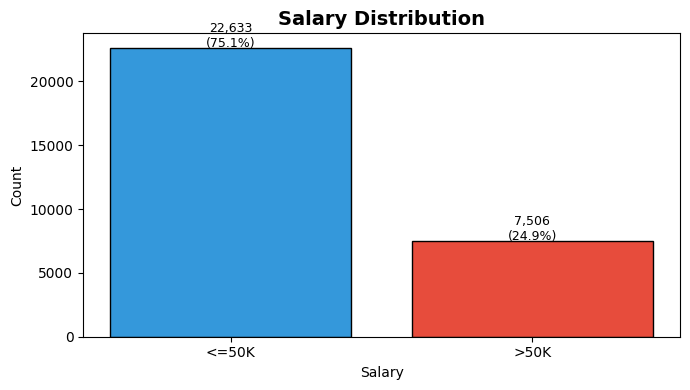

In [5]:
# Salary Distribution
salary_counts = df['salary'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(salary_counts.index, salary_counts.values,
       color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_title('Salary Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Salary')
for i, (_, v) in enumerate(salary_counts.items()):
    ax.text(i, v + 100, f'{v:,}\n({v / len(df) * 100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

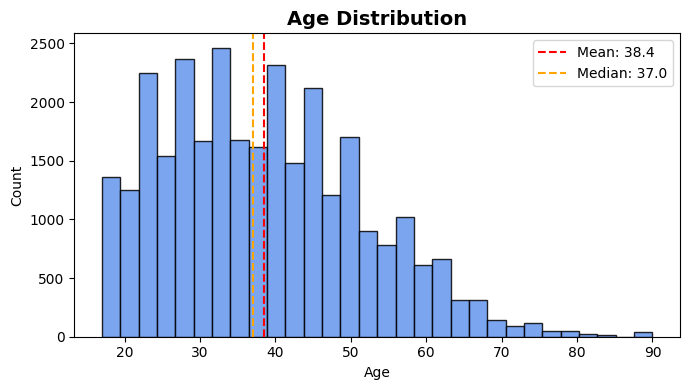

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['age'], bins=30, color='cornflowerblue', edgecolor='black', alpha=0.85)
ax.axvline(df['age'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean: {df['age'].mean():.1f}")
ax.axvline(df['age'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['age'].median():.1f}")
ax.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


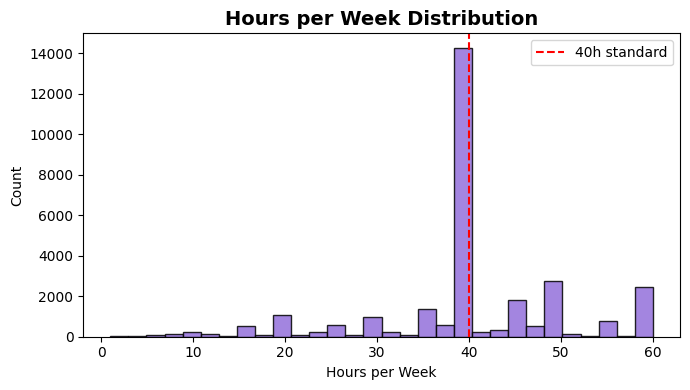

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['hours-per-week'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.85)
ax.axvline(40, color='red', linestyle='--', linewidth=1.5, label='40h standard')
ax.set_title('Hours per Week Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Hours per Week')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

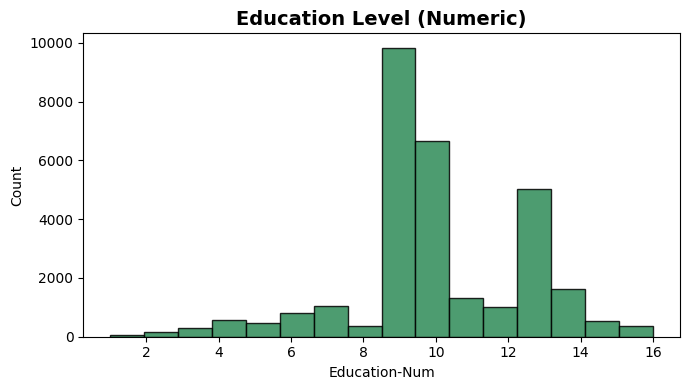

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['education-num'], bins=16, color='seagreen', edgecolor='black', alpha=0.85)
ax.set_title('Education Level (Numeric)', fontsize=14, fontweight='bold')
ax.set_xlabel('Education-Num')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


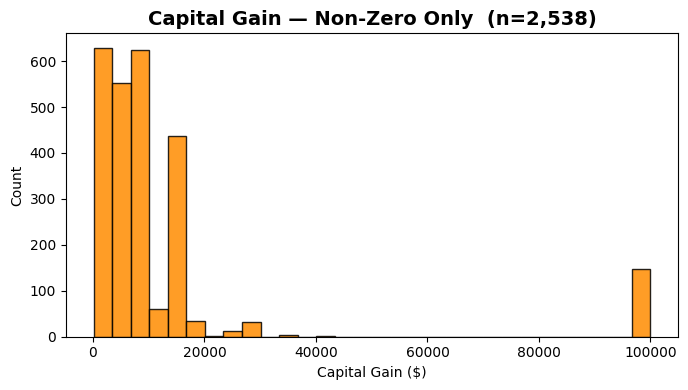

In [9]:
cap_gain_nz = df[df['capital-gain'] > 0]['capital-gain']
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cap_gain_nz, bins=30, color='darkorange', edgecolor='black', alpha=0.85)
ax.set_title(f'Capital Gain — Non-Zero Only  (n={len(cap_gain_nz):,})', fontsize=14, fontweight='bold')
ax.set_xlabel('Capital Gain ($)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

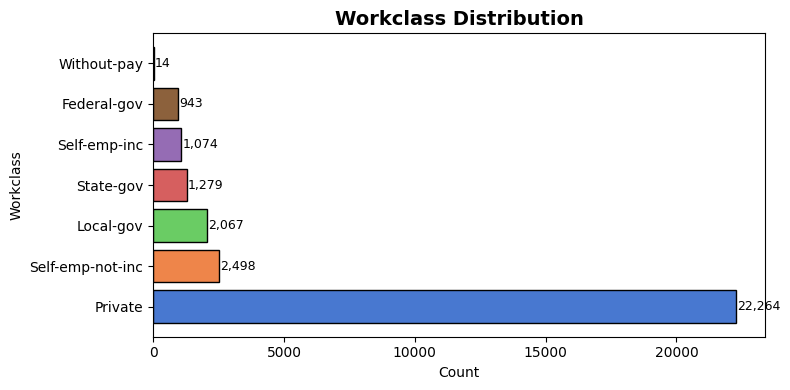

In [10]:
work_class = df['workclass'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(work_class.index, work_class.values,
        color=sns.color_palette('muted', len(work_class)), edgecolor='black')
ax.set_title('Workclass Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('Workclass')
for i, v in enumerate(work_class.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### 2.2 Correlation Analysis

Quantifying linear relationships between numeric features and salary helps us identify which factors are most strongly associated with higher income, guiding our interpretation of the data and informing potential predictive modeling efforts.

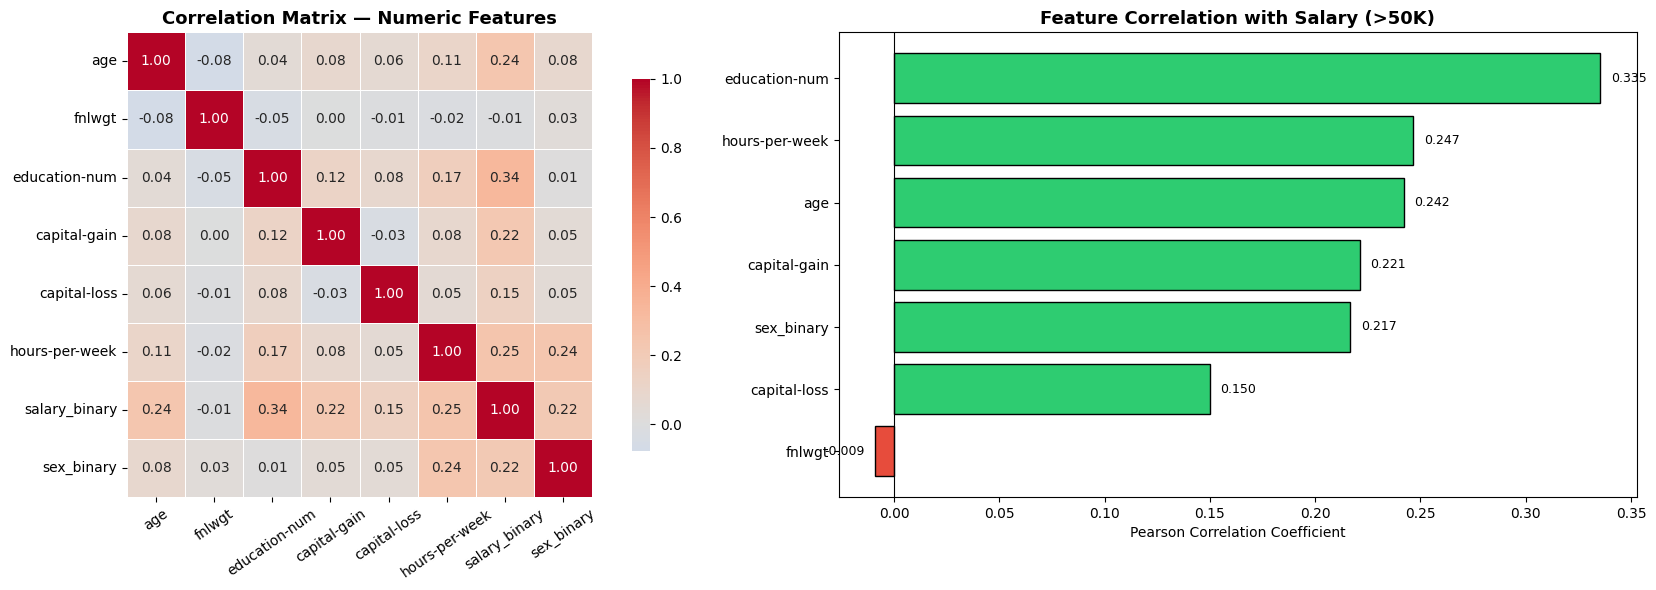


Key insights — features most correlated with earning >50K:
  ↑ education-num        r = 0.335  (positively associated with higher income)
  ↑ hours-per-week       r = 0.247  (positively associated with higher income)
  ↑ age                  r = 0.242  (positively associated with higher income)
  ↑ capital-gain         r = 0.221  (positively associated with higher income)
  ↑ sex_binary           r = 0.217  (positively associated with higher income)
  ↑ capital-loss         r = 0.150  (positively associated with higher income)
  ↓ fnlwgt               r = -0.009  (negatively associated with higher income)


In [11]:
# Encode binary variables so Pearson correlation can measure their relationship with salary

df_corr = df.copy()
df_corr['salary_binary'] = (df_corr['salary'] == '>50K').astype(int)
df_corr['sex_binary'] = (df_corr['sex'] == 'Male').astype(int)

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain',
                'capital-loss', 'hours-per-week', 'salary_binary', 'sex_binary']

corr_matrix = df_corr[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

# Salary correlation bar chart — most actionable view
salary_corr  = corr_matrix['salary_binary'].drop('salary_binary').sort_values()
bar_colors   = ['#e74c3c' if v < 0 else '#2ecc71' for v in salary_corr.values]
axes[1].barh(salary_corr.index, salary_corr.values, color=bar_colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Salary (>50K)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
for i, v in enumerate(salary_corr.values):
    offset = 0.005 if v >= 0 else -0.005
    axes[1].text(v + offset, i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey insights — features most correlated with earning >50K:")
top_pos = salary_corr[salary_corr > 0].sort_values(ascending=False)
top_neg = salary_corr[salary_corr < 0].sort_values()
for col, val in top_pos.items():
    print(f"  ↑ {col:<20} r = {val:.3f}  (positively associated with higher income)")
for col, val in top_neg.items():
    print(f"  ↓ {col:<20} r = {val:.3f}  (negatively associated with higher income)")

#### 2.3 Feature Engineering

Deriving new variables (age group, work intensity, capital flag) allows us to capture complex patterns and interactions that may not be evident from the original features alone, enriching our analysis and enabling deeper insights into the factors influencing income.

In [12]:
# Create derived variables that enrich the analysis with higher-level groupings

# 1. Age group — meaningful life/career stages
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 25, 35, 45, 55, 65, 120],
                          labels=['≤25', '26–35', '36–45', '46–55', '56–65', '65+'])

# 2. Work intensity — categorise weekly hours into labour archetypes
df['work_intensity'] = pd.cut(df['hours-per-week'],
                               bins=[0, 20, 34, 40, 50, 500],
                               labels=['Part-time', 'Reduced', 'Full-time', 'Overtime', 'Extreme'])

# 3. Net capital — investment gain minus loss
df['net_capital'] = df['capital-gain'] - df['capital-loss']

# 4. Capital income flag — whether the person has any investment activity
df['has_capital_income'] = (df['net_capital'] != 0).astype(int)

# 5. Higher education flag — binary indicator for Bachelors/Masters/Doctorate
df['higher_edu'] = df['education'].isin(['Bachelors', 'Masters', 'Doctorate']).astype(int)

print("Engineered features added:")
print(f"  age_group          : {list(df['age_group'].cat.categories)}")
print(f"  work_intensity     : {list(df['work_intensity'].cat.categories)}")
print(f"  net_capital        : min = {df['net_capital'].min():,}  |  max = {df['net_capital'].max():,}")
print(f"  has_capital_income : {df['has_capital_income'].sum():,} people ({df['has_capital_income'].mean()*100:.1f}%)")
print(f"  higher_edu         : {df['higher_edu'].sum():,} people ({df['higher_edu'].mean()*100:.1f}%)")

Engineered features added:
  age_group          : ['≤25', '26–35', '36–45', '46–55', '56–65', '65+']
  work_intensity     : ['Part-time', 'Reduced', 'Full-time', 'Overtime', 'Extreme']
  net_capital        : min = -4,356  |  max = 99,999
  has_capital_income : 3,965 people (13.2%)
  higher_edu         : 7,043 people (23.4%)


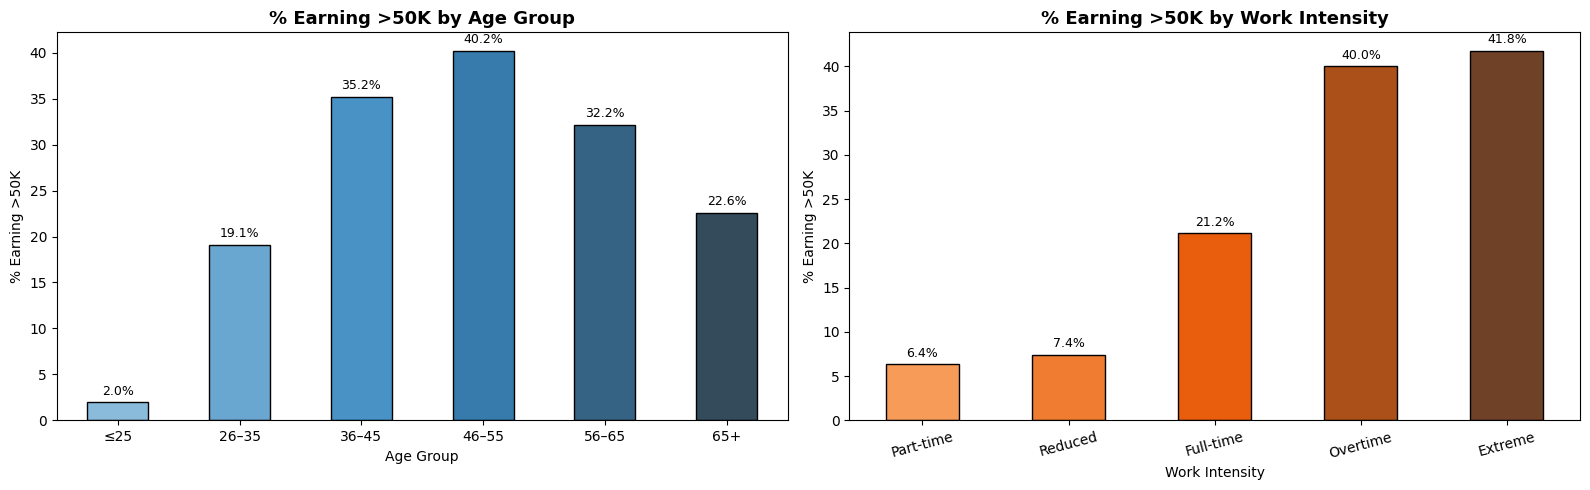

In [13]:
# Visualize salary rate by engineered features
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

age_salary = df.groupby('age_group', observed=True)['salary'].apply(
    lambda x: (x == '>50K').mean() * 100
)
age_salary.plot(kind='bar', ax=axes[0],
                color=sns.color_palette('Blues_d', len(age_salary)), edgecolor='black')
axes[0].set_title('% Earning >50K by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('% Earning >50K')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(age_salary):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

wi_salary = df.groupby('work_intensity', observed=True)['salary'].apply(
    lambda x: (x == '>50K').mean() * 100
)
wi_salary.plot(kind='bar', ax=axes[1],
               color=sns.color_palette('Oranges_d', len(wi_salary)), edgecolor='black')
axes[1].set_title('% Earning >50K by Work Intensity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Work Intensity')
axes[1].set_ylabel('% Earning >50K')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(wi_salary):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 🧑‍🤝‍🧑 3. Race Distribution

Counting the number of individuals from each racial group in the dataset.

Race Count:
 race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64


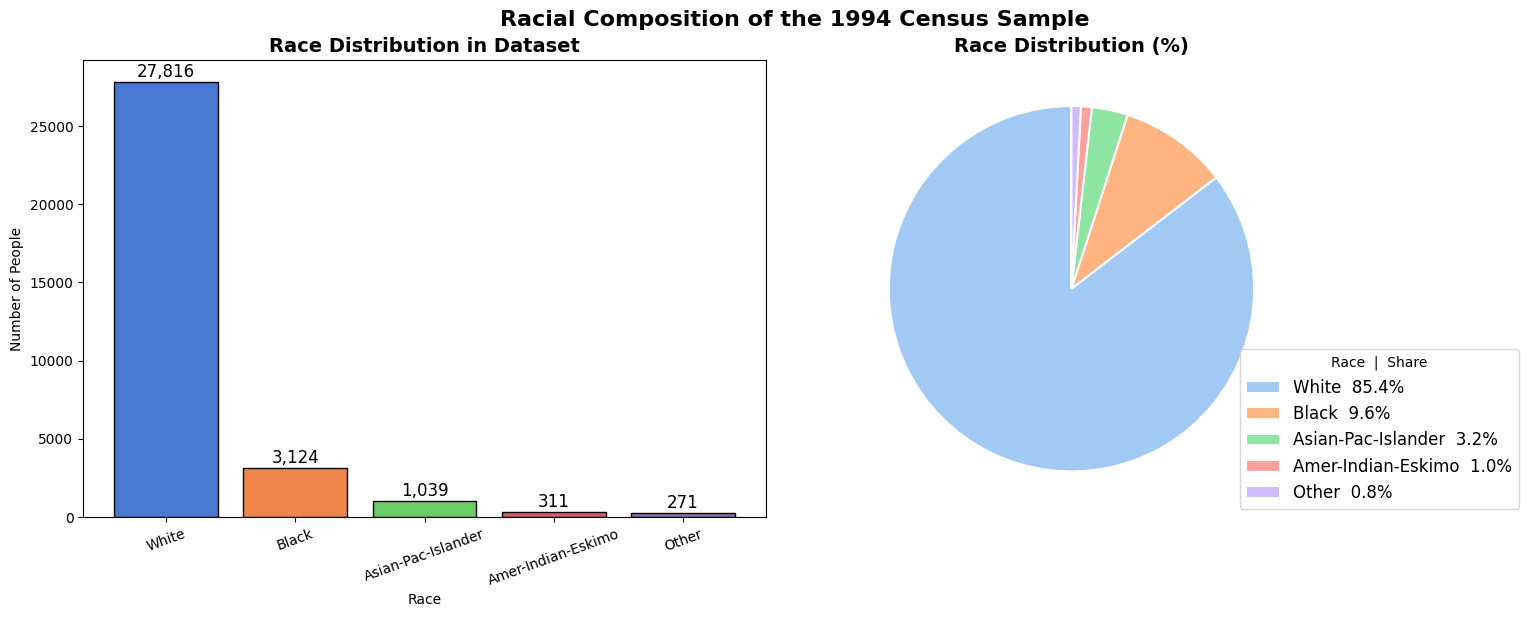

In [14]:
race_count = df_raw['race'].value_counts()
print("Race Count:\n", race_count)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].bar(race_count.index, race_count.values,
                   color=sns.color_palette('muted', len(race_count)), edgecolor='black')
axes[0].set_title('Race Distribution in Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('Number of People')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, race_count.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=12)

# Pie chart — no inline labels, use legend instead
palette     = sns.color_palette('pastel', len(race_count))
total       = race_count.sum()
pct_labels  = [f'{v / total * 100:.1f}%' for v in race_count.values]
legend_labels = [f'{race}  {pct}' for race, pct in zip(race_count.index, pct_labels)]

wedges, _ = axes[1].pie(
    race_count.values,
    labels=None,           # no inline labels
    startangle=90,
    colors=palette,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

axes[1].legend(
    wedges,
    legend_labels,
    title='Race  |  Share',
    title_fontsize=10,
    loc='lower left',
    bbox_to_anchor=(0.85, 0, 0.5, 1),
    fontsize=12,
    frameon=True
)
axes[1].set_title('Race Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.suptitle('Racial Composition of the 1994 Census Sample', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 👨 4. Age Analysis

Exploring the age distribution across the dataset and computing the average age of male respondents.

Average age of men: 39.4 years
Average age of women: 36.9 years
Overall average age: 38.6 years


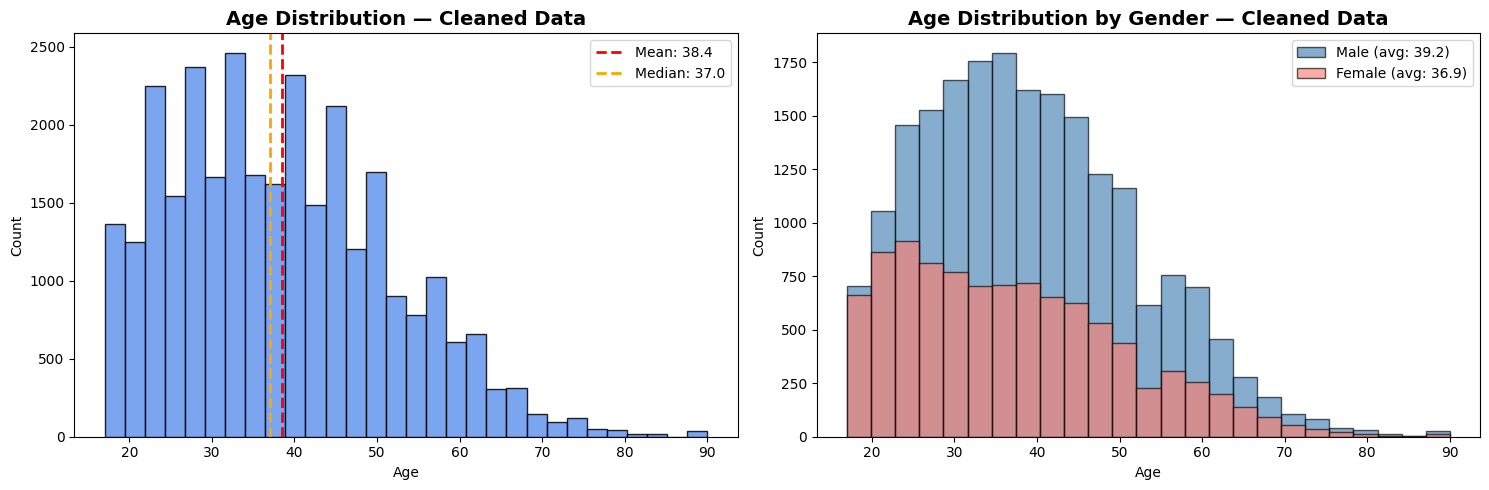

In [15]:
average_age_men = round(df_raw[df_raw['sex'] == 'Male']['age'].mean(), 1)
print(f"Average age of men: {average_age_men} years")
print(f"Average age of women: {round(df_raw[df_raw['sex'] == 'Female']['age'].mean(), 1)} years")
print(f"Overall average age: {round(df_raw['age'].mean(), 1)} years")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['age'], bins=30, color='cornflowerblue', edgecolor='black', alpha=0.85)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['age'].mean():.1f}")
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df['age'].median():.1f}")
axes[0].set_title('Age Distribution — Cleaned Data', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

for sex, color in [('Male', 'steelblue'), ('Female', 'salmon')]:
    axes[1].hist(df[df['sex'] == sex]['age'], bins=25, alpha=0.65,
                 label=f"{sex} (avg: {round(df[df['sex']==sex]['age'].mean(),1)})",
                 color=color, edgecolor='black')
axes[1].set_title('Age Distribution by Gender — Cleaned Data', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### 🎓 5. Education & Salary Analysis

Examining how education level (specifically higher education vs. lower education) relates to earning more than $50K/year.

In [16]:
percentage_bachelors = round(
    df_raw['education'].value_counts(normalize=True)['Bachelors'] * 100, 1
)

higher_education = df_raw[df_raw['education'].isin(['Bachelors', 'Masters', 'Doctorate'])]
lower_education  = df_raw[~df_raw['education'].isin(['Bachelors', 'Masters', 'Doctorate'])]

higher_education_rich = round((higher_education['salary'] == '>50K').mean() * 100, 1)
lower_education_rich  = round((lower_education['salary']  == '>50K').mean() * 100, 1)

print(f"  Percentage with Bachelor's degree : {percentage_bachelors}%")
print(f"  Higher education earning >50K     : {higher_education_rich}%")
print(f"  Lower education earning >50K      : {lower_education_rich}%")
print(f"  Advantage of higher education     : +{round(higher_education_rich - lower_education_rich, 1)}%")

  Percentage with Bachelor's degree : 16.4%
  Higher education earning >50K     : 46.5%
  Lower education earning >50K      : 17.4%
  Advantage of higher education     : +29.1%


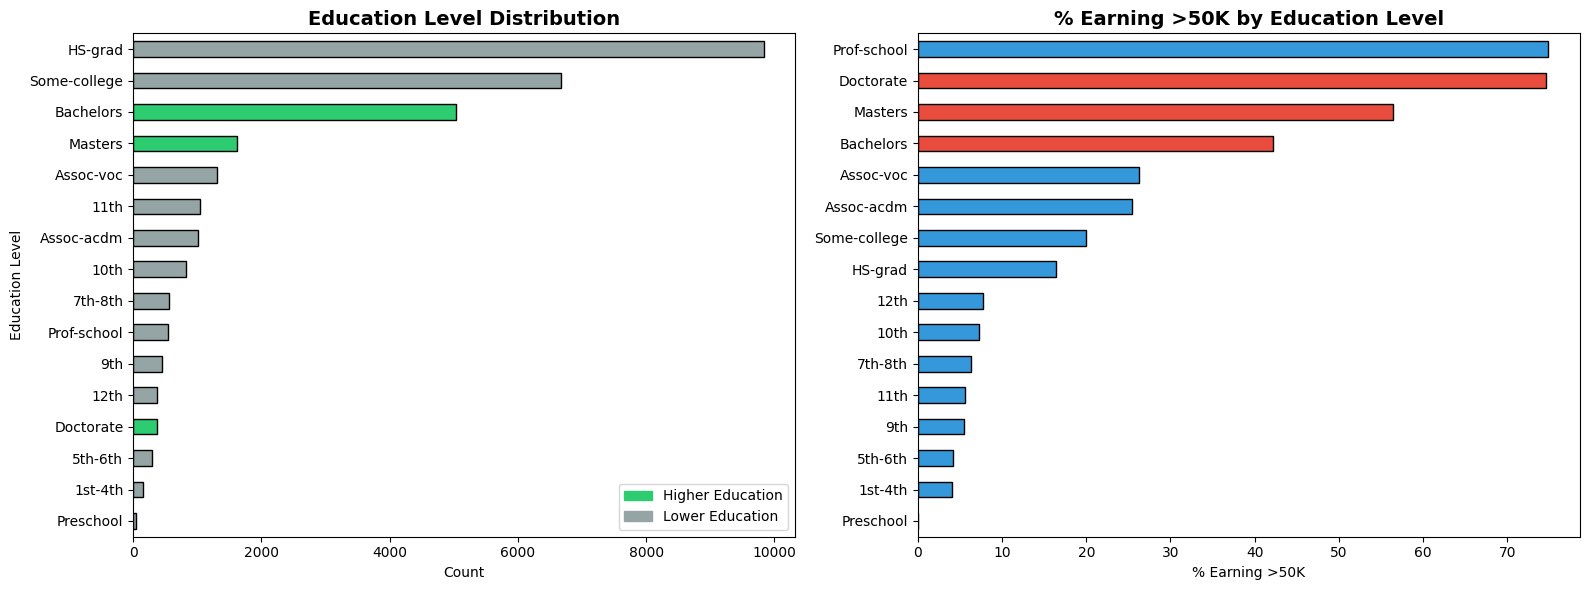

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Education level distribution
edu_counts = df['education'].value_counts().sort_values(ascending=True)
colors = ['#2ecc71' if e in ['Bachelors', 'Masters', 'Doctorate'] else '#95a5a6'
          for e in edu_counts.index]
edu_counts.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Education Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Education Level')

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#2ecc71', label='Higher Education'),
    Patch(color='#95a5a6', label='Lower Education')
])

# % earning >50K by education level
salary_by_edu = (
    df.groupby('education')['salary']
      .apply(lambda x: (x == '>50K').mean() * 100)
      .sort_values(ascending=True)
)
colors2 = ['#e74c3c' if e in ['Bachelors', 'Masters', 'Doctorate'] else '#3498db'
           for e in salary_by_edu.index]
salary_by_edu.plot(kind='barh', ax=axes[1], color=colors2, edgecolor='black')
axes[1].set_title('% Earning >50K by Education Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('% Earning >50K')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### ⏰ 6. Work Hours Analysis

Finding the minimum number of hours worked per week and examining the salary distribution of those minimum-hour workers.

Minimum hours worked per week      : 1
Workers at minimum hours           : 20
% of min-hour workers earning >50K : 10.0%


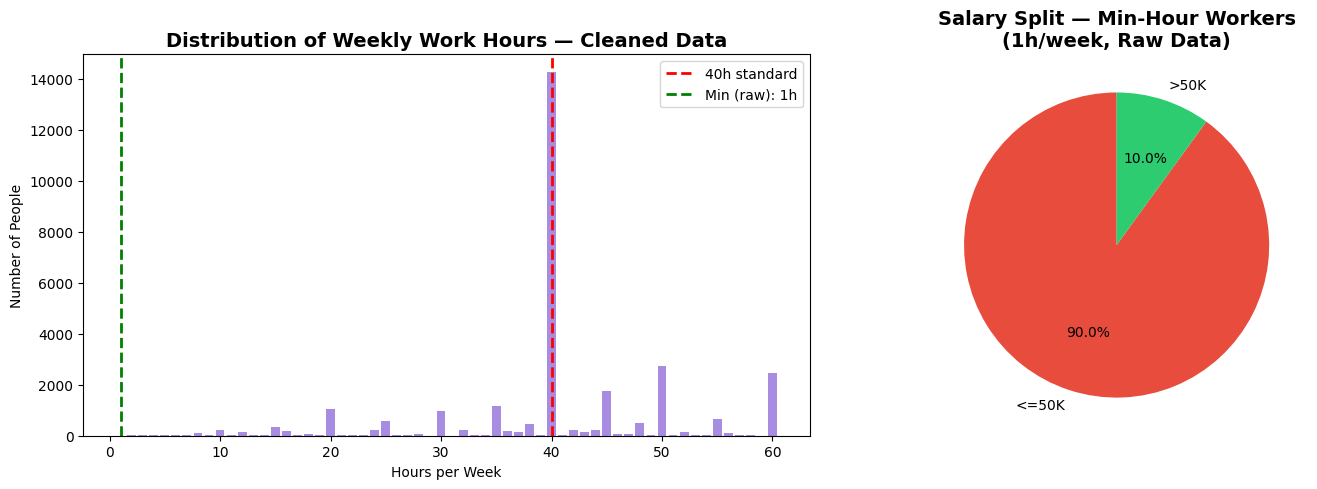

In [18]:
min_work_hours  = int(df_raw['hours-per-week'].min())
num_min_workers = df_raw[df_raw['hours-per-week'] == min_work_hours]
rich_percentage = round((num_min_workers['salary'] == '>50K').mean() * 100, 1)

print(f"Minimum hours worked per week      : {min_work_hours}")
print(f"Workers at minimum hours           : {len(num_min_workers)}")
print(f"% of min-hour workers earning >50K : {rich_percentage}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hours_dist = df['hours-per-week'].value_counts().sort_index()
axes[0].bar(hours_dist.index, hours_dist.values, color='mediumpurple', edgecolor='none', alpha=0.8)
axes[0].axvline(40, color='red', linestyle='--', linewidth=2, label='40h standard')
axes[0].axvline(min_work_hours, color='green', linestyle='--', linewidth=2,
                label=f'Min (raw): {min_work_hours}h')
axes[0].set_title('Distribution of Weekly Work Hours — Cleaned Data', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hours per Week')
axes[0].set_ylabel('Number of People')
axes[0].legend()

salary_split = num_min_workers['salary'].value_counts()
axes[1].pie(salary_split.values, labels=salary_split.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title(f'Salary Split — Min-Hour Workers\n({min_work_hours}h/week, Raw Data)',
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 🌎 7. Country-Salary Analysis

Identifying which country has the highest percentage of residents earning more than $50K/year.

Country with highest % of >50K earners : Iran
Percentage                             : 41.9%


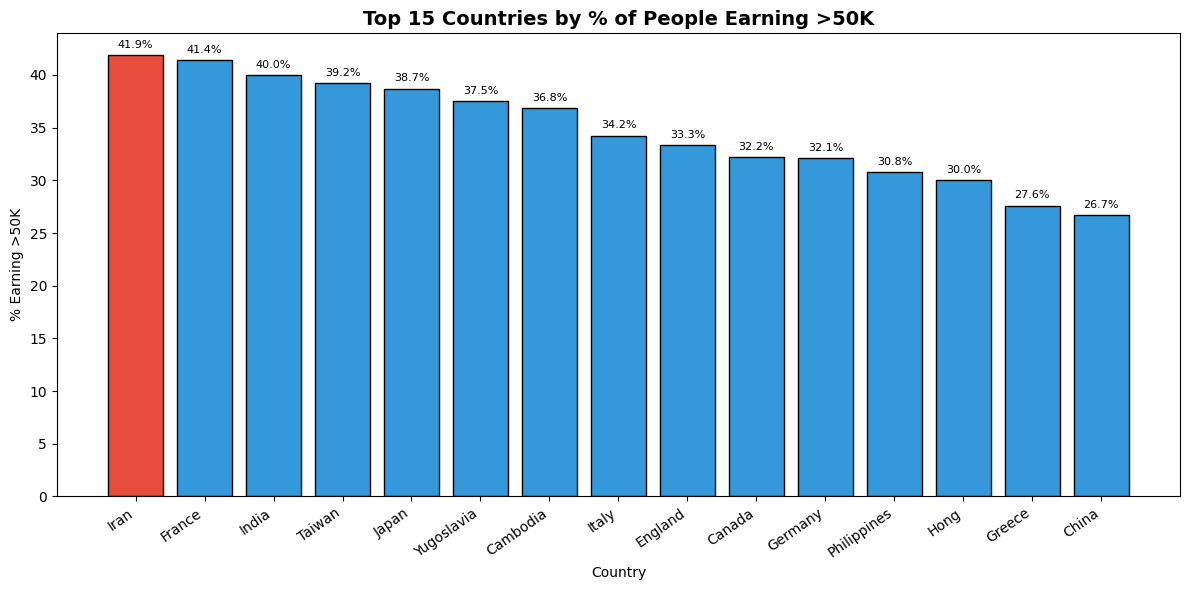

In [19]:
country_salary_pct = (
    df_raw[df_raw['salary'] == '>50K']['native-country'].value_counts()
    / df_raw['native-country'].value_counts()
) * 100

highest_earning_country     = country_salary_pct.idxmax()
highest_earning_country_pct = round(country_salary_pct.max(), 1)

print(f"Country with highest % of >50K earners : {highest_earning_country}")
print(f"Percentage                             : {highest_earning_country_pct}%")

top_countries = country_salary_pct.dropna().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if c == highest_earning_country else '#3498db' for c in top_countries.index]
bars = plt.bar(range(len(top_countries)), top_countries.values, color=colors, edgecolor='black')
plt.xticks(range(len(top_countries)), top_countries.index, rotation=35, ha='right')
plt.title('Top 15 Countries by % of People Earning >50K', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('% Earning >50K')
for bar, val in zip(bars, top_countries.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 🇮🇳 8. Top Occupation in India (>50K Earners)

Finding the most popular occupation among residents from India who earn more than $50K/year.

Top occupation in India for >50K earners: Prof-specialty
Total India residents earning >50K: 40


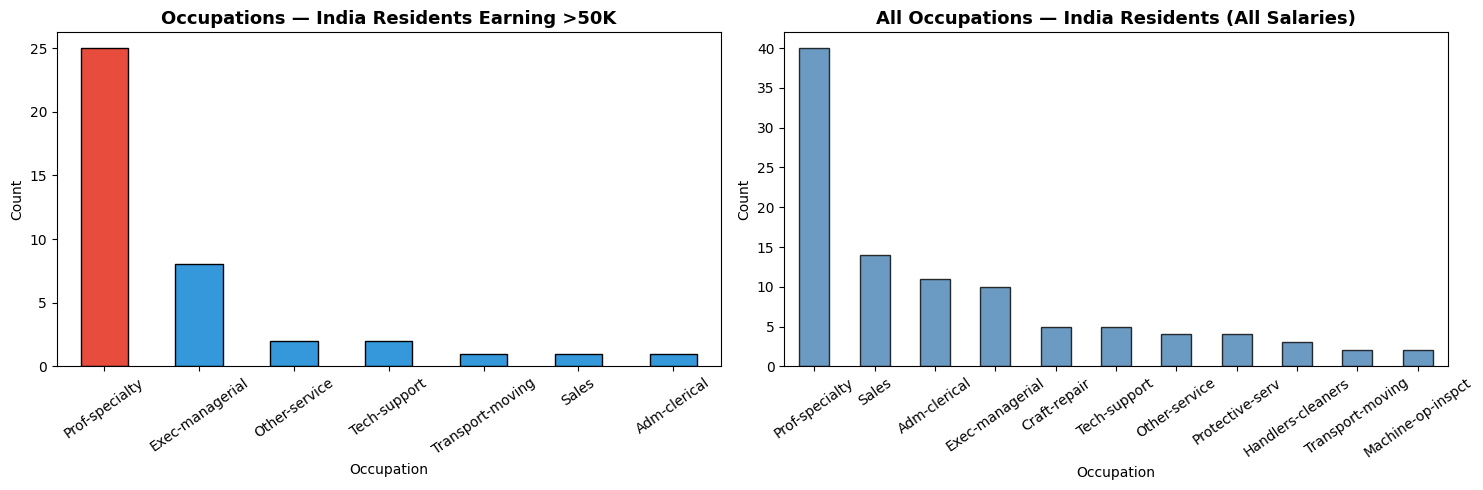

In [20]:
india_rich = df_raw[(df_raw['native-country'] == 'India') & (df_raw['salary'] == '>50K')]
top_IN_occupation = india_rich['occupation'].value_counts().idxmax()

print(f"Top occupation in India for >50K earners: {top_IN_occupation}")
print(f"Total India residents earning >50K: {len(india_rich)}")

india_occ = india_rich['occupation'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#e74c3c' if occ == top_IN_occupation else '#3498db' for occ in india_occ.index]
india_occ.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Occupations — India Residents Earning >50K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Occupation')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)

india_all_occ = df_raw[df_raw['native-country'] == 'India']['occupation'].value_counts()
india_all_occ.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('All Occupations — India Residents (All Salaries)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Occupation')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

### 📊 9. Summary of Results

Compiling all computed answers into a single structured output.

In [21]:
results = {
    'race_count'                        : race_count,
    'average_age_men'                   : average_age_men,
    'percentage_bachelors'              : percentage_bachelors,
    'higher_education_rich'             : higher_education_rich,
    'lower_education_rich'              : lower_education_rich,
    'min_work_hours'                    : min_work_hours,
    'rich_percentage'                   : rich_percentage,
    'highest_earning_country'           : highest_earning_country,
    'highest_earning_country_percentage': highest_earning_country_pct,
    'top_IN_occupation'                 : top_IN_occupation,
}

print("=" * 55)
print("         DEMOGRAPHIC DATA ANALYSIS — RESULTS")
print("=" * 55)
print(f"  Race count:\n{race_count.to_string()}")
print(f"\n  Average age of men                  : {average_age_men}")
print(f"  % with Bachelor's degree            : {percentage_bachelors}%")
print(f"  Higher education earns >50K         : {higher_education_rich}%")
print(f"  Lower education earns >50K          : {lower_education_rich}%")
print(f"  Minimum work hours/week             : {min_work_hours}")
print(f"  % rich among min-hour workers       : {rich_percentage}%")
print(f"  Highest earning country             : {highest_earning_country}")
print(f"  Highest earning country %           : {highest_earning_country_pct}%")
print(f"  Top occupation in India (>50K)      : {top_IN_occupation}")
print("=" * 55)

         DEMOGRAPHIC DATA ANALYSIS — RESULTS
  Race count:
race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271

  Average age of men                  : 39.4
  % with Bachelor's degree            : 16.4%
  Higher education earns >50K         : 46.5%
  Lower education earns >50K          : 17.4%
  Minimum work hours/week             : 1
  % rich among min-hour workers       : 10.0%
  Highest earning country             : Iran
  Highest earning country %           : 41.9%
  Top occupation in India (>50K)      : Prof-specialty
